In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749496203.144399  178923 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749496203.148688  178923 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749496203.162063  178923 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749496203.162088  178923 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749496203.162090  178923 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749496203.162092  178923 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 9: Advanced Deep Learning for Computer Vision

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

We previously introduced you to the basic components of a convnet and how convolutional and maxpooling layers
work.  We looked at some simple deep learning models for computer vision, stacks of `Conv2D` and `MaxPooling2D` layers.

In this section we will look at other types of computer vision tasks than image classification.

## 9.3 Modern Convnet Architecture Patterns

### 9.3.1 Modularity, Hierarchy and Reuse

### 9.3.2 Residual Connections

Here is an example of a simple convnet structured into
a series of blocks, each made of two convolution layers and one optional
max pooling layer, with a residual connection around each block.

In [4]:
def residual_block(x, filters, pooling=False):
    """Example of a utility function and reuse in Keras function API.
    This creates a block that applies a convolution and sets up a
    residual connection around it, with an option to add
    a max pooling layer.

    Parameters
    ----------
    x : input
      The input coming into the block we want to add as residual after the block
    filters : int
      The size of the Conv2D filters to create in 2 convolution layers
    pooling : bool (default False)
      Option to also add a pooling layer downsample 2x and setup residual around it as well
    """
    residual = x
    # 2 consecutive convolution layers using filters specified added as block
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)

    # if asked to use pooling, add strided convolution to project the residual into
    # expected shape after downsampling
    if pooling:
        x = layers.MaxPooling2D(2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2)(residual)
    # if we don't use max pooling, only need to project residual if number
    # of filter channels has changed
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1)(residual)
    x = layers.add([x, residual])
    return x

In [5]:
# start of model Input, shape 32x32 with 3 channels
# and rescale to floats as usual expecting RGB int inputs
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

# create first block with residual connection around it, has
# a max pooling layer that does 2x downsampling
x = residual_block(x, filters=32, pooling=True)

# create second block, note increasing filter count, again 2x downsampling using pooling
x = residual_block(x, filters=64, pooling=True)

# last block doesn't need a max pooling layer since we apply global average pooling right after it.
x = residual_block(x, filters=128, pooling=False)

# apply global average pooling after last block
x = layers.GlobalAveragePooling2D()(x)

# output layer for simple binary classification task
outputs = layers.Dense(1, activation="sigmoid")(x)

# create the model
model = keras.Model(inputs=inputs, outputs=outputs)

I0000 00:00:1749496206.387481  178923 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Lets look at the model summary, and also lets draw the model architecture graph.
Before you look at this, can you predict the layers and network graph with these
type of residual connections that were added?

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        128 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │      2,112 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ max_pooling2d_1[… │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │      8,320 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

The textual list of layers is a bit hard to visualize.  Residual connections effectively constitute nonsequential branches in the
network architecture.  So visualizing the network connection graph can be helpful here.  For example:

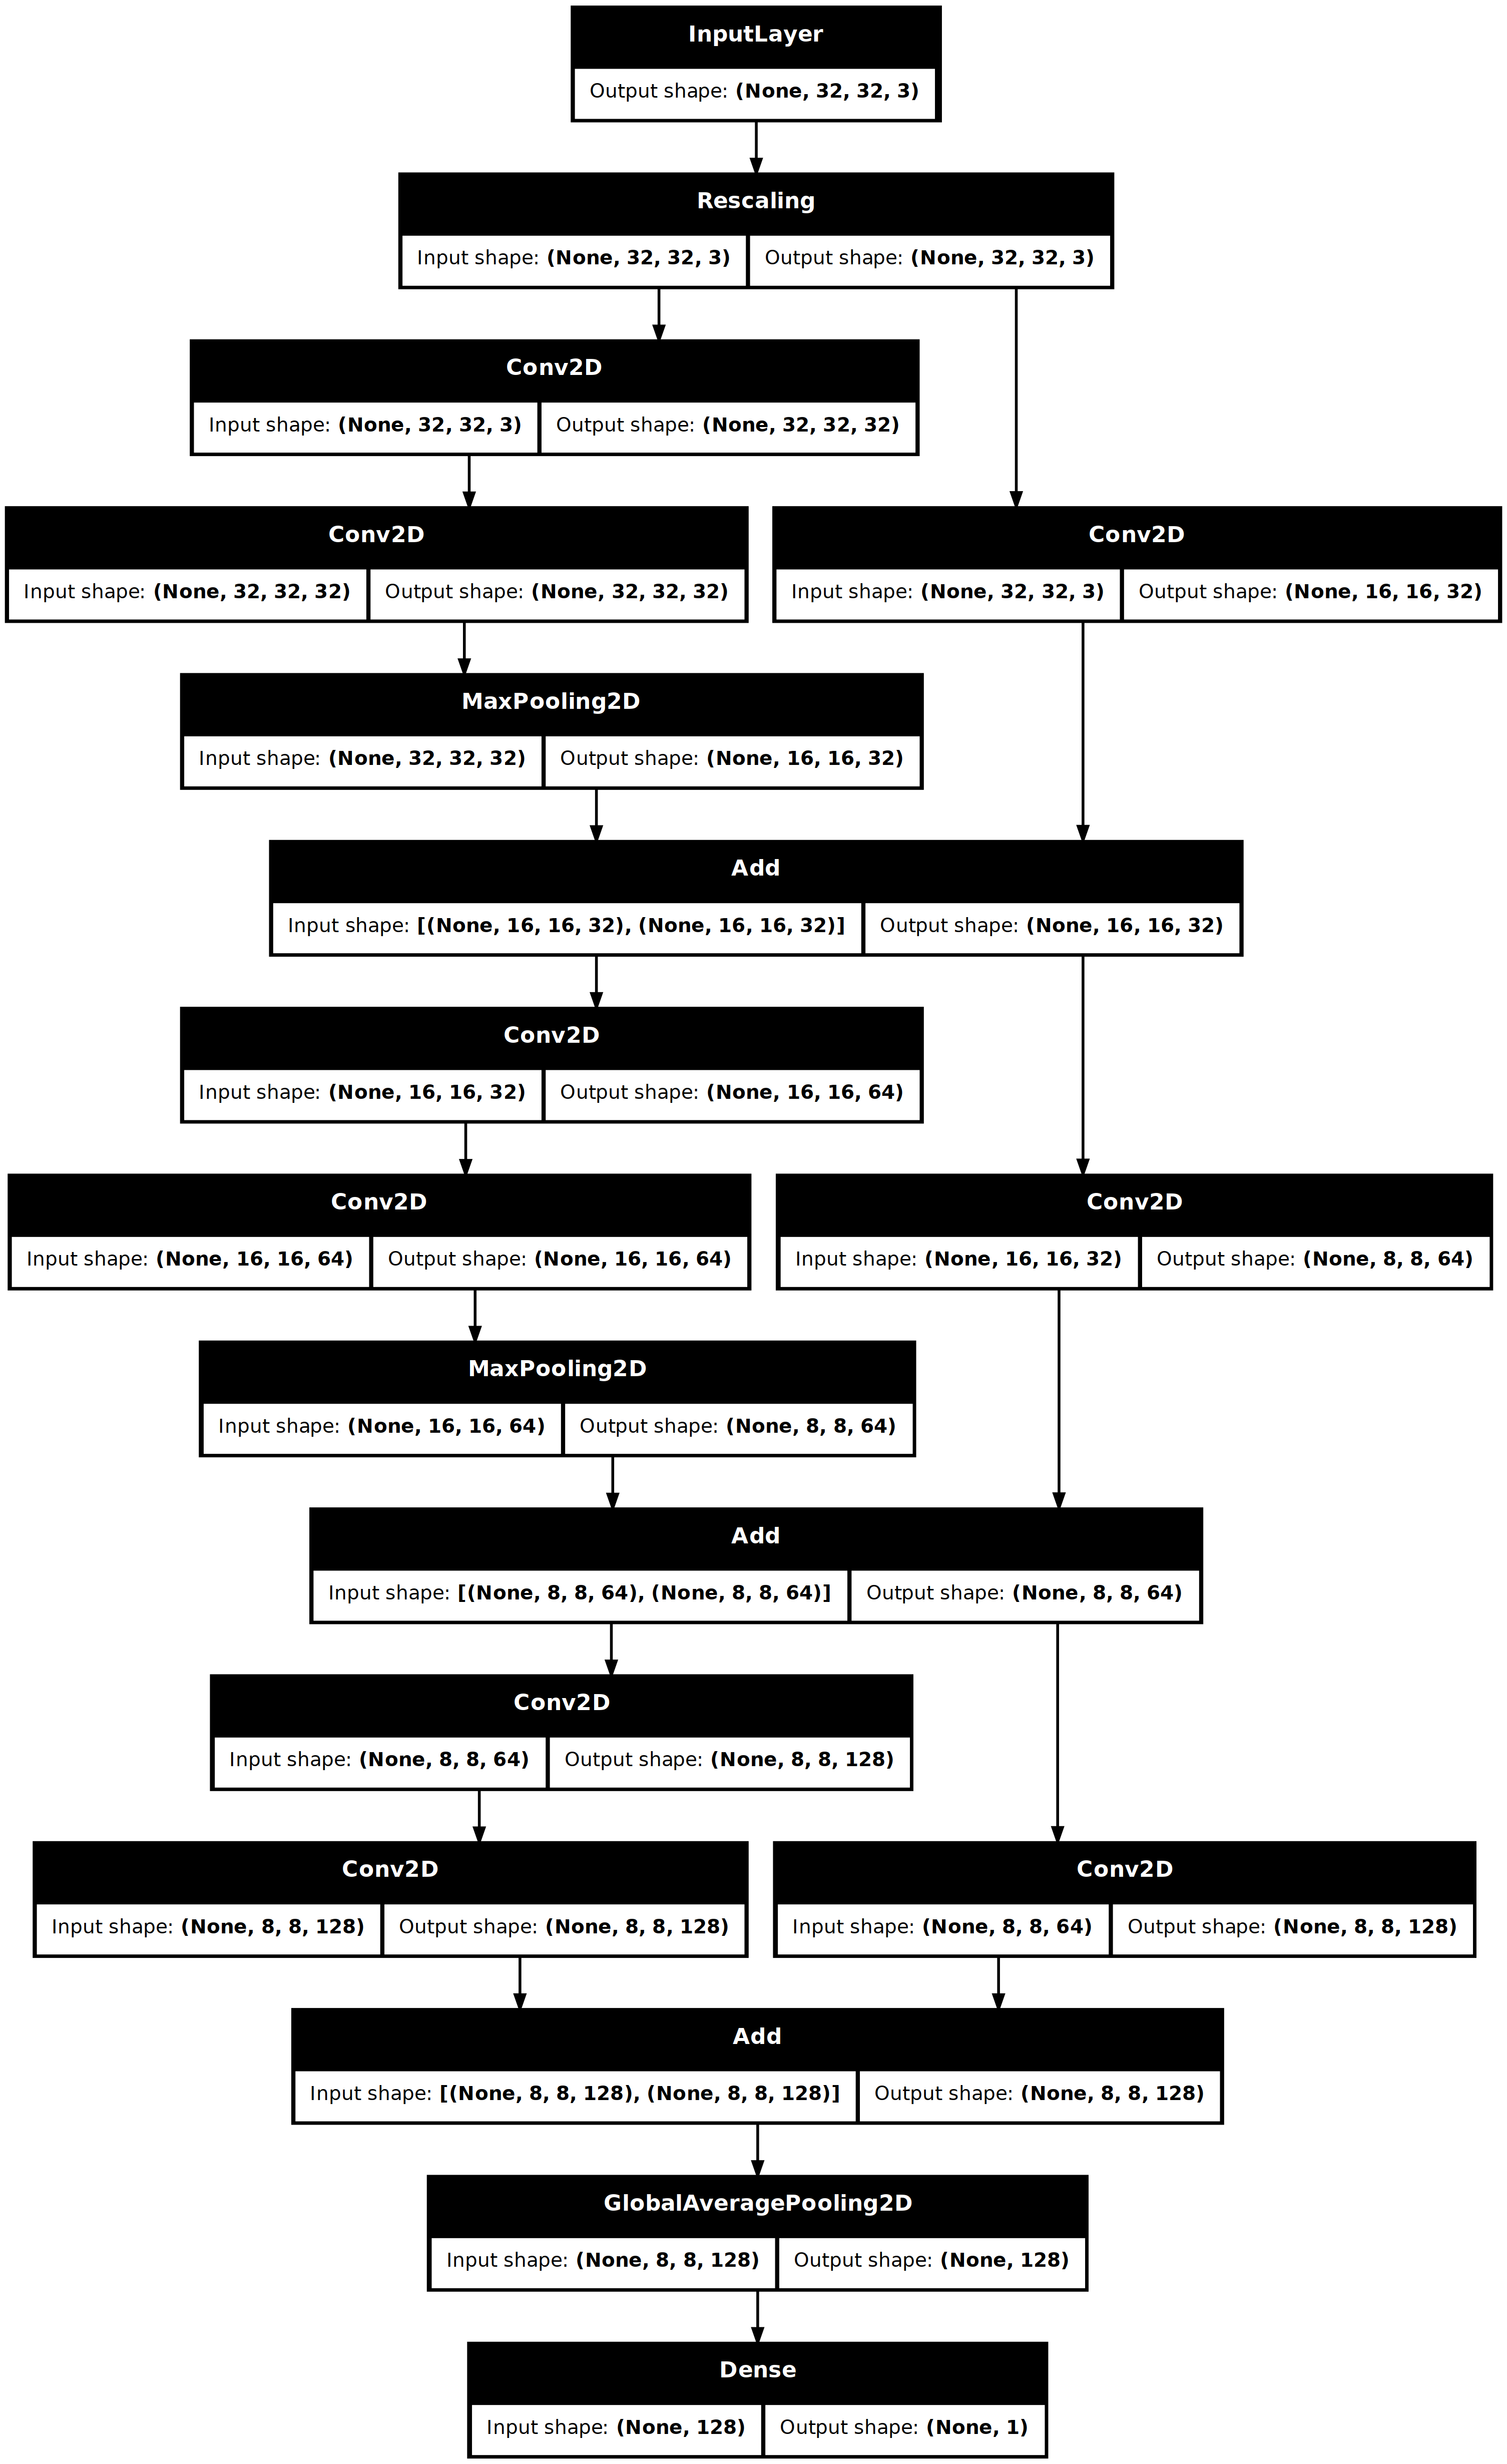

In [8]:
keras.utils.plot_model(model, "../figures/residual-connections-example-model.png", show_shapes=True)

### 9.3.3 Batch Normalization

### 9.3.4 Depthwise separable convolutions

### Summary of Convenet Best Practices: Residual Connections, Batch Normalization and Depthwise Separable Convolutions

Some of the important things to keep in mind about the Convnet Architecture design and the 3 specific convnet architecture elements we just discussed

<font color='blue'>

- Your model should be organized into repeated **blocks** of layers, usually made of multiple convolution layers
  and a max pooling layer.
- The number of filters in your layers should increse as the size of the spatial feature maps decreases.
- Deep and narrow is better than broad and shallow.
- Intoducing residual connections around blocks of layers helps you train deeper networks
  (avoids vanishing gradients)
- It can be beneficial to introduce batch normalization layers after your convolution layers
  (though reason why these work remain controversial, may also just be helping reduce vanishing gradients).
- It can be beneficial to replace `Conv2D` layers with `SeparableConv2D` layers, which are more
  parameter-efficient.
